In [1]:
import pandas as pd
import sqlite3
df = pd.read_csv('online_retail_II.csv')  

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  


In [2]:
df.dropna(subset=['Customer ID'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['Revenue'] = df['Quantity'] * df['Price']

print("After cleaning:", df.shape)

After cleaning: (805549, 9)


In [3]:
customers = df[['Customer ID', 'Country']]\
            .drop_duplicates()\
            .rename(columns={'Customer ID': 'CustomerID'})

transactions = df[['Invoice', 'Customer ID',
                   'StockCode', 'Description',
                   'Quantity', 'Price',
                   'InvoiceDate', 'Revenue']]\
               .rename(columns={'Customer ID': 'CustomerID'})

print("Customers table:", customers.shape)
print("Transactions table:", transactions.shape)

Customers table: (5891, 2)
Transactions table: (805549, 8)


In [4]:
conn = sqlite3.connect(':memory:')

customers.to_sql('customers', conn, 
                 index=False, if_exists='replace')
transactions.to_sql('transactions', conn, 
                    index=False, if_exists='replace')

print("Tables ready in SQL!")

Tables ready in SQL!


In [6]:
sql_query = """
SELECT 
    c.CustomerID,
    c.Country,
    COUNT(DISTINCT t.Invoice)  AS Frequency,
    ROUND(SUM(t.Revenue), 2)   AS Monetary,
    MAX(t.InvoiceDate)         AS LastPurchase
FROM customers c
JOIN transactions t 
    ON c.CustomerID = t.CustomerID
GROUP BY c.CustomerID, c.Country
ORDER BY Monetary DESC
"""

rfm_raw = pd.read_sql_query(sql_query, conn)
print("\nSQL JOIN Output:")
print(rfm_raw.head(10))


SQL JOIN Output:
   CustomerID         Country  Frequency   Monetary         LastPurchase
0     18102.0  United Kingdom        145  608821.65  2011-12-09 11:50:00
1     14646.0     Netherlands        151  528602.52  2011-12-08 12:12:00
2     14156.0            EIRE        156  313946.37  2011-11-30 10:54:00
3     14911.0            EIRE        398  295972.63  2011-12-08 15:54:00
4     17450.0  United Kingdom         51  246973.09  2011-12-01 13:29:00
5     13694.0  United Kingdom        143  196482.81  2011-12-06 09:32:00
6     17511.0  United Kingdom         60  175603.55  2011-12-07 10:12:00
7     16446.0  United Kingdom          2  168472.50  2011-12-09 09:15:00
8     16684.0  United Kingdom         55  147142.77  2011-12-05 14:06:00
9     12415.0       Australia         28  144458.37  2011-11-15 14:22:00


In [7]:
rfm_raw['LastPurchase'] = pd.to_datetime(rfm_raw['LastPurchase'])
snapshot = rfm_raw['LastPurchase'].max() + pd.Timedelta(days=1)
rfm_raw['Recency'] = (snapshot - rfm_raw['LastPurchase']).dt.days


In [8]:
rfm = rfm_raw[['CustomerID', 'Country', 
               'Recency', 'Frequency', 'Monetary']]

print("\n✅ Final RFM Table:")
print(rfm.head(10))
print("\nStats:")
print(rfm.describe().round(2))

conn.close()


✅ Final RFM Table:
   CustomerID         Country  Recency  Frequency   Monetary
0     18102.0  United Kingdom        1        145  608821.65
1     14646.0     Netherlands        2        151  528602.52
2     14156.0            EIRE       10        156  313946.37
3     14911.0            EIRE        1        398  295972.63
4     17450.0  United Kingdom        8         51  246973.09
5     13694.0  United Kingdom        4        143  196482.81
6     17511.0  United Kingdom        3         60  175603.55
7     16446.0  United Kingdom        1          2  168472.50
8     16684.0  United Kingdom        4         55  147142.77
9     12415.0       Australia       24         28  144458.37

Stats:
       CustomerID  Recency  Frequency   Monetary
count     5891.00  5891.00     5891.0    5891.00
mean     15309.03   201.11        6.3    3021.34
std       1718.89   209.26       13.0   14722.21
min      12346.00     1.00        1.0       2.95
25%      13823.50    26.00        1.0     349.34
50%    

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# remove outlier

q99 = rfm['Monetary'].quantile(0.99)
rfm_clean = rfm[rfm['Monetary'] <= q99].copy()
print(f"Removed outliers. Remaining: {len(rfm_clean)} customers")

Removed outliers. Remaining: 5832 customers


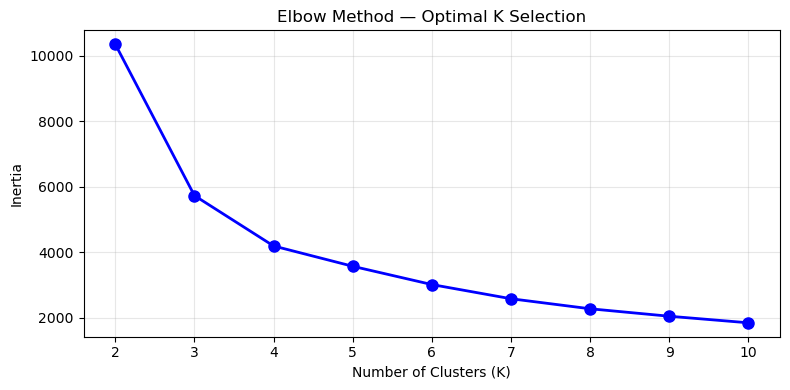

Elbow chart paaru — curve bend aana point = best K!


In [10]:
# Scale (Mandatory before clustering!)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_clean[['Recency', 'Frequency', 'Monetary']]
)

# Elbow Method — finding the best K
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Elbow Chart
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K Selection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print("Elbow chart paaru — curve bend aana point = best K!")

In [11]:
# K=4 applying (elbow paathu adjust pannalam)

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster summary

summary = rfm_clean.groupby('Cluster').agg(
    Count         = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean')
).round(1)

print("\nCluster Summary:")
print(summary)
print("\nLook at summary — assign persona manually!")


Cluster Summary:
         Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                 
0          849         48.6           13.6        5385.0
1         1863        475.7            2.0         652.9
2          195         31.2           32.1       15616.1
3         2925         84.9            3.7        1127.6

Look at summary — assign persona manually!


In [12]:
# assign the persona
# Check the summary and align it with your values
persona_map = {
    0: 'Champions',
    1: 'At-Risk',
    2: 'Regular Customers',
    3: 'New Customers'
}
rfm_clean['Persona'] = rfm_clean['Cluster'].map(persona_map)

print("\nPersona Count:")
print(rfm_clean['Persona'].value_counts())


Persona Count:
Persona
New Customers        2925
At-Risk              1863
Champions             849
Regular Customers     195
Name: count, dtype: int64


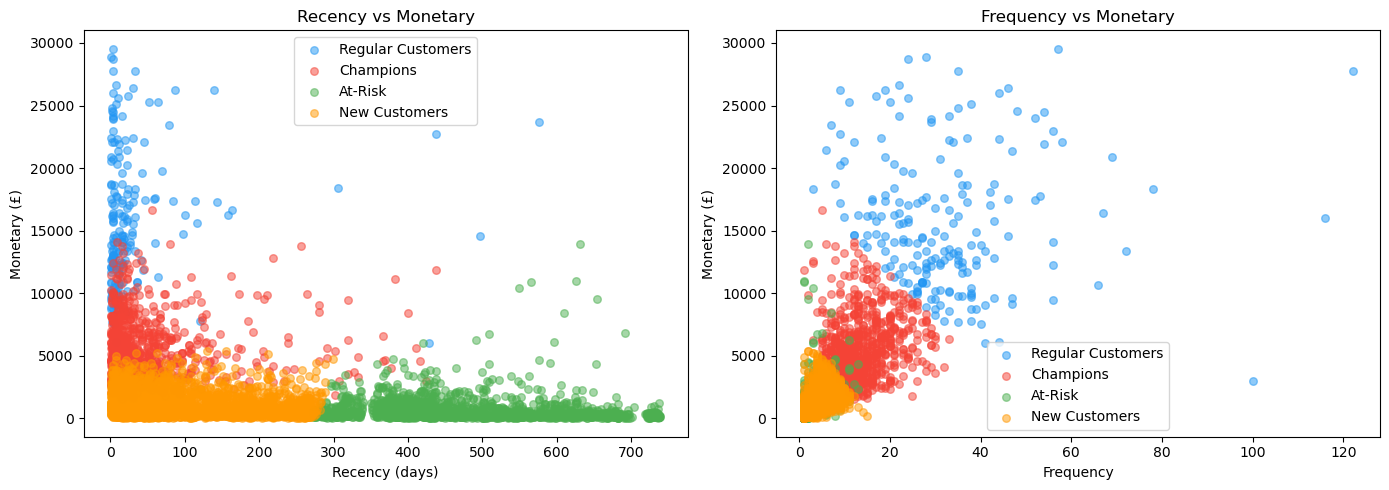

Cluster plots saved!


In [13]:
# Cluster Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
personas = rfm_clean['Persona'].unique()

# Plot 1: Recency vs Monetary
for i, p in enumerate(personas):
    sub = rfm_clean[rfm_clean['Persona'] == p]
    axes[0].scatter(sub['Recency'], sub['Monetary'],
                    label=p, alpha=0.5, s=30, color=colors[i])
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary')
axes[0].legend()

# Plot 2: Frequency vs Monetary
for i, p in enumerate(personas):
    sub = rfm_clean[rfm_clean['Persona'] == p]
    axes[1].scatter(sub['Frequency'], sub['Monetary'],
                    label=p, alpha=0.5, s=30, color=colors[i])
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()
print("Cluster plots saved!")

In [15]:
# WEEK 3: CLV CALCULATION

#  CLV ingredients calculate
snapshot = rfm_clean['Monetary'].copy()

# Average Purchase Value (APV)
total_revenue   = transactions['Revenue'].sum()
total_orders    = transactions['Invoice'].nunique()
avg_purchase_value = total_revenue / total_orders

# Purchase Frequency
total_customers    = len(rfm_clean)
purchase_frequency = total_orders / total_customers

# Customer Lifespan (per customer)
lifespan_df = transactions.groupby('CustomerID')['InvoiceDate'].agg(
    first_date = 'min',
    last_date  = 'max'
).reset_index()

lifespan_df['InvoiceDate'] = pd.to_datetime(lifespan_df['first_date'])
lifespan_df['lifespan_days'] = (
    pd.to_datetime(lifespan_df['last_date']) - 
    pd.to_datetime(lifespan_df['first_date'])
).dt.days

avg_lifespan_years = lifespan_df['lifespan_days'].mean() / 365

print("=" * 45)
print(f"Avg Purchase Value  : £{avg_purchase_value:.2f}")
print(f"Purchase Frequency  : {purchase_frequency:.2f} orders/customer")
print(f"Avg Lifespan        : {avg_lifespan_years:.2f} years")
print("=" * 45)

Avg Purchase Value  : £479.95
Purchase Frequency  : 6.34 orders/customer
Avg Lifespan        : 0.75 years


In [16]:
# CLV per customer
rfm_clean['Avg_Order_Value'] = (
    rfm_clean['Monetary'] / rfm_clean['Frequency']
)
rfm_clean['CLV'] = (
    rfm_clean['Avg_Order_Value'] * 
    rfm_clean['Frequency'] * 
    avg_lifespan_years
).round(2)

print("\nCLV added to RFM table:")
print(rfm_clean[['CustomerID','Persona',
                  'Recency','Frequency',
                  'Monetary','CLV']].head(10))


CLV added to RFM table:
    CustomerID            Persona  Recency  Frequency  Monetary       CLV
59     13078.0  Regular Customers        3         57  29532.45  22090.47
60     13098.0  Regular Customers        1         28  28882.44  21604.26
61     17857.0  Regular Customers        4         24  28682.24  21454.51
62     14527.0  Regular Customers        3        122  27792.30  20788.83
63     15513.0  Regular Customers       33         35  27750.55  20757.60
64     16333.0  Regular Customers        8         22  26626.80  19917.03
65     17865.0  Regular Customers       31         46  26374.39  19728.22
66     18251.0  Regular Customers       87          9  26278.86  19656.76
67     13802.0  Regular Customers      139         19  26259.11  19641.99
68     15498.0  Regular Customers        3         44  26039.58  19477.78


In [17]:
# CLV by Segment
clv_summary = rfm_clean.groupby('Persona').agg(
    Total_Customers = ('CustomerID',  'count'),
    Avg_CLV         = ('CLV',         'mean'),
    Total_CLV       = ('CLV',         'sum'),
    Avg_Recency     = ('Recency',     'mean'),
    Avg_Frequency   = ('Frequency',   'mean'),
    Avg_Monetary    = ('Monetary',    'mean')
).round(2).sort_values('Avg_CLV', ascending=False)

print("\n📊 CLV by Segment:")
print(clv_summary)


📊 CLV by Segment:
                   Total_Customers   Avg_CLV   Total_CLV  Avg_Recency  \
Persona                                                                 
Regular Customers              195  11680.94  2277783.37        31.19   
Champions                      849   4028.01  3419783.10        48.62   
New Customers                 2925    843.47  2467156.11        84.88   
At-Risk                       1863    488.34   909784.25       475.72   

                   Avg_Frequency  Avg_Monetary  
Persona                                         
Regular Customers          32.12      15616.09  
Champions                  13.59       5385.00  
New Customers               3.67       1127.63  
At-Risk                     2.03        652.86  


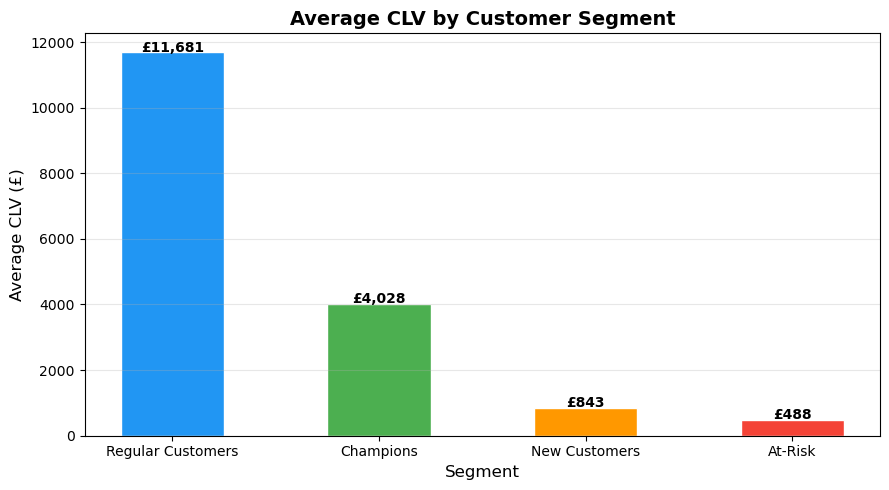

CLV chart saved!


In [18]:
# CLV Bar Chart
plt.figure(figsize=(9, 5))
bars = plt.bar(
    clv_summary.index,
    clv_summary['Avg_CLV'],
    color=['#2196F3','#4CAF50','#FF9800','#F44336'],
    edgecolor='white', width=0.5
)
plt.title('Average CLV by Customer Segment', 
          fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average CLV (£)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, clv_summary['Avg_CLV']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'£{val:,.0f}',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('clv_by_segment.png', dpi=150)
plt.show()
print("CLV chart saved!")

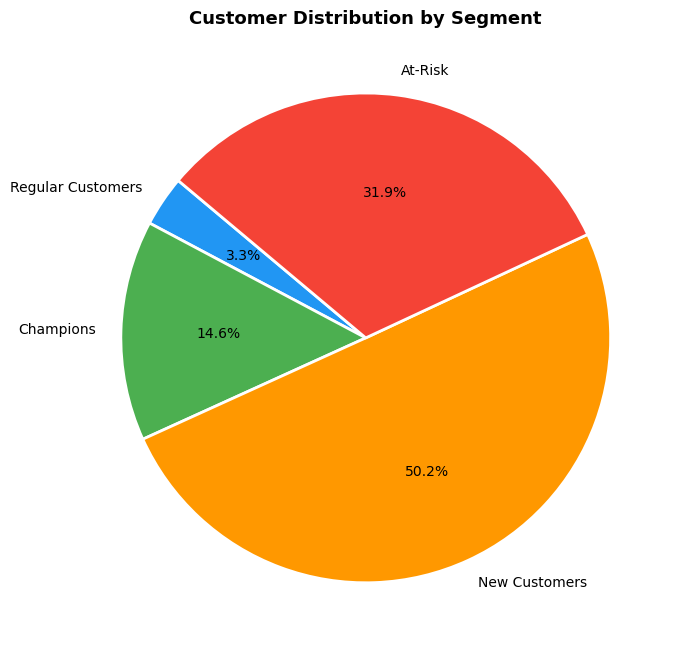

Pie chart saved!


In [22]:
# Pie chart — Customer Distribution
plt.figure(figsize=(7, 7))
plt.pie(
    clv_summary['Total_Customers'],
    labels=clv_summary.index,
    autopct='%1.1f%%',
    colors=['#2196F3','#4CAF50','#FF9800','#F44336'],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Customer Distribution by Segment',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_pie.png', dpi=150)
plt.show()
print("Pie chart saved!")

In [24]:
print("\n" + "="*55)
print("        BUSINESS RECOMMENDATIONS")
print("="*55)

for persona in clv_summary.index:
    row = clv_summary.loc[persona]
    print(f"""
  {persona}
  Customers  : {int(row['Total_Customers'])}
  Avg CLV    : £{row['Avg_CLV']:,.2f}
  Total CLV  : £{row['Total_CLV']:,.2f}
  Avg Orders : {row['Avg_Frequency']:.1f}
""")


        BUSINESS RECOMMENDATIONS

  Regular Customers
  Customers  : 195
  Avg CLV    : £11,680.94
  Total CLV  : £2,277,783.37
  Avg Orders : 32.1


  Champions
  Customers  : 849
  Avg CLV    : £4,028.01
  Total CLV  : £3,419,783.10
  Avg Orders : 13.6


  New Customers
  Customers  : 2925
  Avg CLV    : £843.47
  Total CLV  : £2,467,156.11
  Avg Orders : 3.7


  At-Risk
  Customers  : 1863
  Avg CLV    : £488.34
  Total CLV  : £909,784.25
  Avg Orders : 2.0



In [27]:
# Export files
rfm_clean.to_csv('rfm_clv_final.csv', index=False)
clv_summary.to_csv('clv_summary.csv')

print("Files exported:")
print("  rfm_clv_final.csv  ← Power BI / Tableau used")
print("  clv_summary.csv    ← paste in report")
print("\n✅ Project 2 Complete!")

Files exported:
  rfm_clv_final.csv  ← Power BI / Tableau used
  clv_summary.csv    ← paste in report

✅ Project 2 Complete!
